# SpaceX Falcon 9 Launch Success Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load SpaceX Falcon 9 Dataset

In [2]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
df = pd.read_csv(url)
print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 90
Columns: 18


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


# Data Understanding and Initial Exploration

In [3]:
df.columns

Index(['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit',
       'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs',
       'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude',
       'Class'],
      dtype='object')

In [5]:
df.isnull().sum()

FlightNumber       0
Date               0
BoosterVersion     0
PayloadMass        0
Orbit              0
LaunchSite         0
Outcome            0
Flights            0
GridFins           0
Reused             0
Legs               0
LandingPad        26
Block              0
ReusedCount        0
Serial             0
Longitude          0
Latitude           0
Class              0
dtype: int64

# Exploratory Data Analysis with Visualization


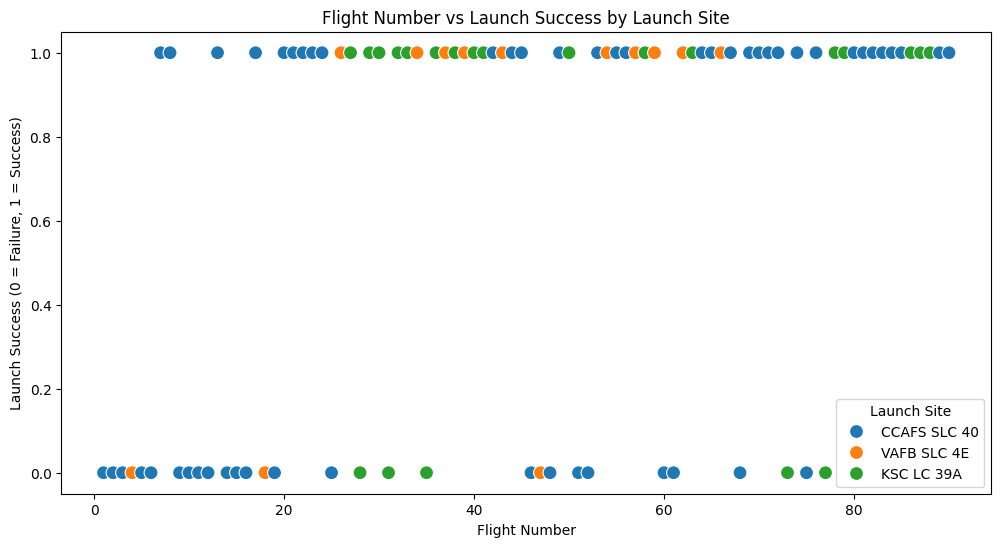

In [6]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df,
    x="FlightNumber",
    y="Class",
    hue="LaunchSite",
    s=100
)

plt.title("Flight Number vs Launch Success by Launch Site")
plt.xlabel("Flight Number")
plt.ylabel("Launch Success (0 = Failure, 1 = Success)")
plt.legend(title="Launch Site")
plt.show()

# Payload Mass vs Launch Success

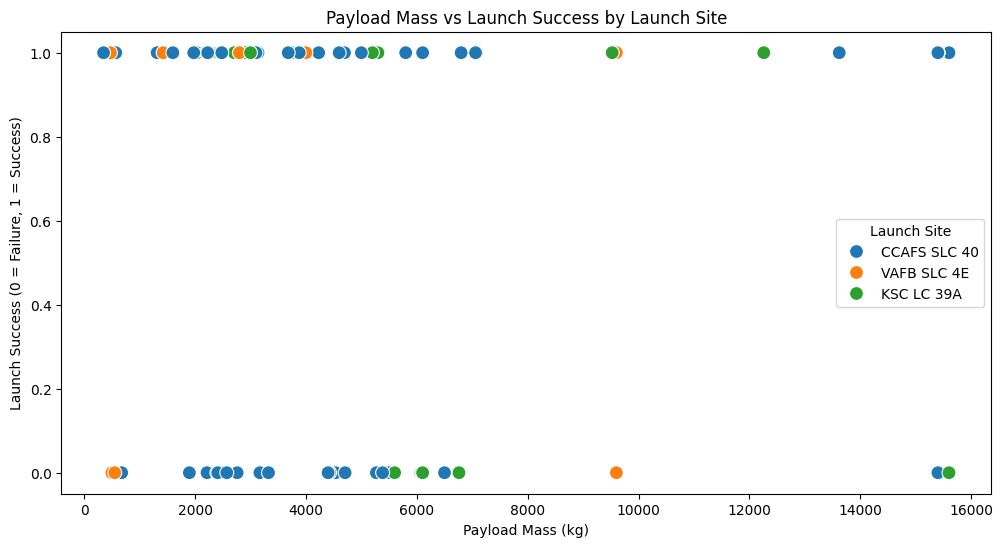

In [9]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df,
    x="PayloadMass",
    y="Class",
    hue="LaunchSite",
    s=100
)

plt.title("Payload Mass vs Launch Success by Launch Site")
plt.xlabel("Payload Mass (kg)")
plt.ylabel("Launch Success (0 = Failure, 1 = Success)")
plt.legend(title="Launch Site")
plt.show()

# Step 6: Launch Success Rate by Orbit

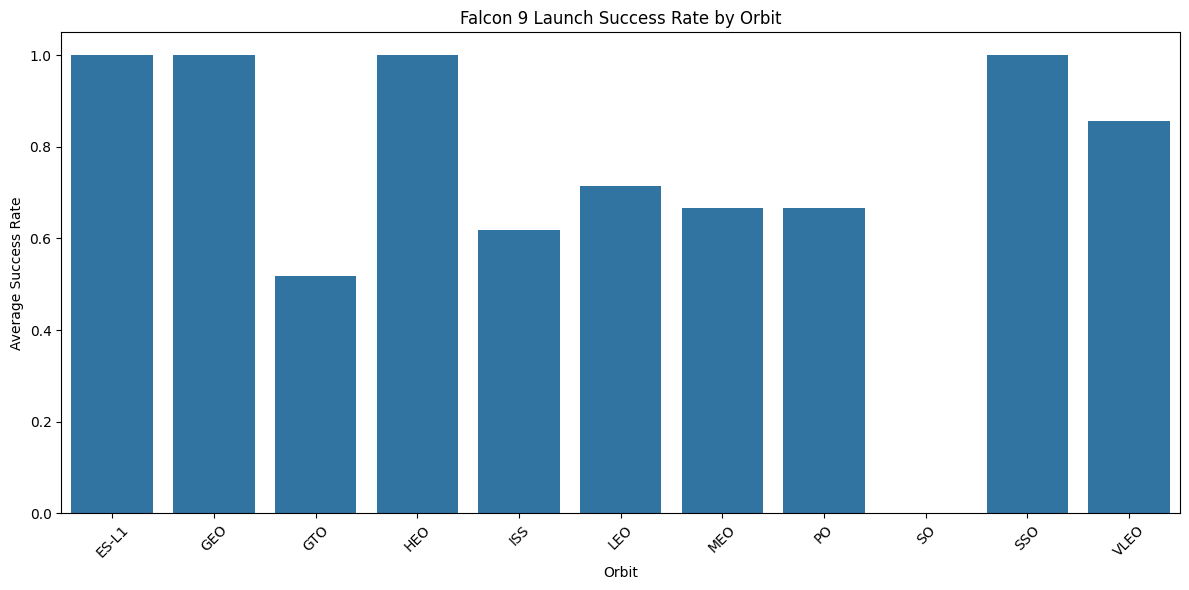

In [10]:
orbit_success = (
    df.groupby("Orbit")["Class"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=orbit_success,
    x="Orbit",
    y="Class"
)

plt.title("Falcon 9 Launch Success Rate by Orbit")
plt.xlabel("Orbit")
plt.ylabel("Average Success Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Relationship Between Flight Number and Launch Success

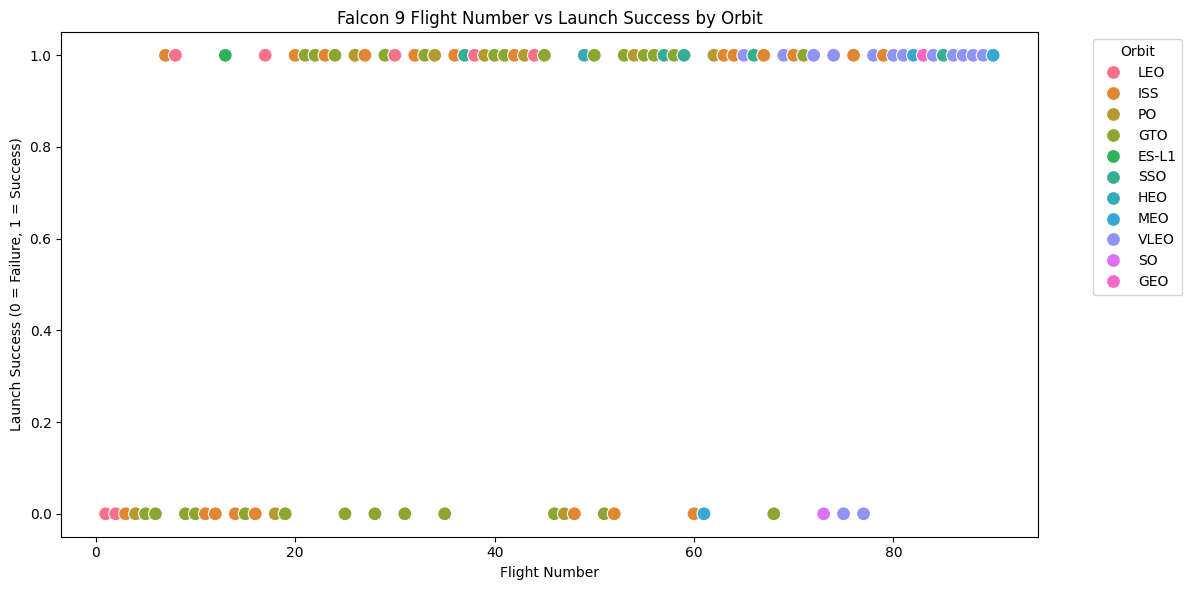

In [12]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df,
    x="FlightNumber",
    y="Class",
    hue="Orbit",
    s=100
)

plt.title("Falcon 9 Flight Number vs Launch Success by Orbit")
plt.xlabel("Flight Number")
plt.ylabel("Launch Success (0 = Failure, 1 = Success)")
plt.legend(title="Orbit", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

##  Launch Success Rate by Launch Site

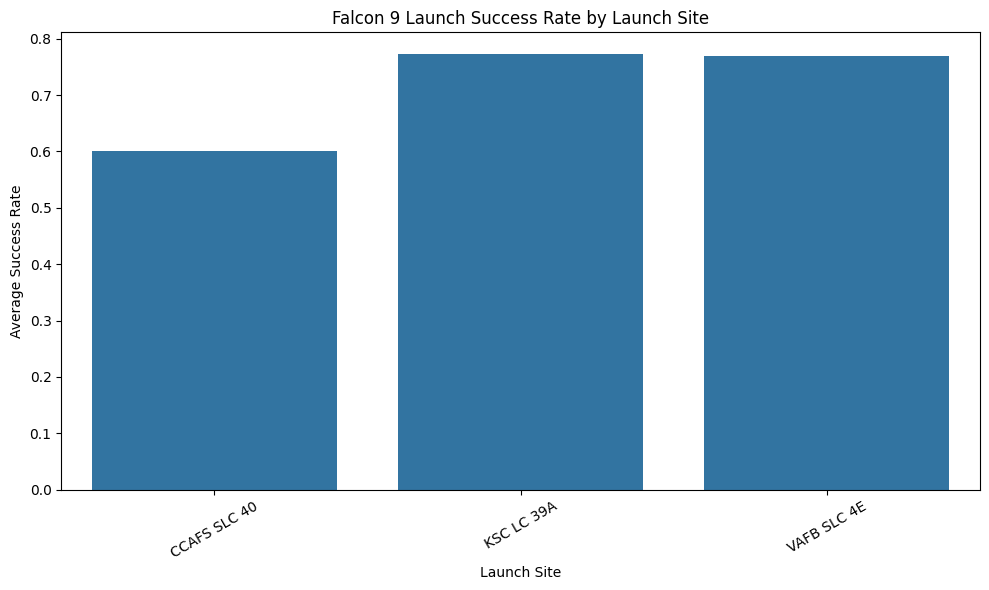

In [14]:
site_success = (
    df.groupby("LaunchSite")["Class"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=site_success,
    x="LaunchSite",
    y="Class"
)

plt.title("Falcon 9 Launch Success Rate by Launch Site")
plt.xlabel("Launch Site")
plt.ylabel("Average Success Rate")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Exploratory Data Analysis with SQL


In [15]:
import sqlite3

conn = sqlite3.connect(":memory:")
df.to_sql("SPACEXTBL", conn, index=False, if_exists="replace")

90

In [17]:
pd.read_sql("""
SELECT LaunchSite,
       COUNT(*) AS Total_Launches,
       ROUND(AVG(Class), 2) AS Success_Rate
FROM SPACEXTBL
GROUP BY LaunchSite
ORDER BY Success_Rate DESC;
""", conn)

,LaunchSite,Total_Launches,Success_Rate
0,VAFB SLC 4E,13,0.77
1,KSC LC 39A,22,0.77
2,CCAFS SLC 40,55,0.60


In [18]:
pd.read_sql("""
SELECT Orbit,
       COUNT(*) AS Total_Launches,
       ROUND(AVG(PayloadMass), 2) AS Average_Payload_Mass,
       ROUND(AVG(Class), 2) AS Success_Rate
FROM SPACEXTBL
GROUP BY Orbit
ORDER BY Success_Rate DESC;
""", conn)

,Orbit,Total_Launches,Average_Payload_Mass,Success_Rate
0,SSO,5,2060.00,1.00
1,HEO,1,350.00,1.00
2,GEO,1,6104.96,1.00
3,ES-L1,1,570.00,1.00
4,VLEO,14,15315.71,0.86
5,LEO,7,3882.84,0.71
6,PO,9,7583.67,0.67
7,MEO,3,3987.00,0.67
8,ISS,21,3279.94,0.62
9,GTO,27,5011.99,0.52


In [19]:
pd.read_sql("""
SELECT LaunchSite,
       ROUND(MAX(PayloadMass), 2) AS Maximum_Payload,
       ROUND(MIN(PayloadMass), 2) AS Minimum_Payload
FROM SPACEXTBL
GROUP BY LaunchSite;
""", conn)

,LaunchSite,Maximum_Payload,Minimum_Payload
0,CCAFS SLC 40,15600.0,350.0
1,KSC LC 39A,15600.0,2490.0
2,VAFB SLC 4E,9600.0,475.0


## Interactive Map of Falcon 9 Launch Sites


In [25]:
import folium

launch_sites = {
    "CCAFS SLC 40": [28.563197, -80.576820],
    "VAFB SLC 4E": [34.632834, -120.610745],
    "KSC LC 39A": [28.573255, -80.646895]
}

spacex_map = folium.Map(
    location=[29.5, -95],
    zoom_start=4
)

for site, coordinates in launch_sites.items():
    folium.Marker(
        location=coordinates,
        popup=site,
        tooltip=site
    ).add_to(spacex_map)

spacex_map

## Launch Success and Failure on the Interactive Map


In [33]:
import folium

site_coords = {
    "CCAFS SLC 40": [28.563197, -80.576820],
    "VAFB SLC 4E": [34.632834, -120.610745],
    "KSC LC 39A": [28.573255, -80.646895]
}

outcome_map = folium.Map(
    location=[29.5, -95],
    zoom_start=4
)

for _, row in df.iterrows():
    site = row["LaunchSite"]

    if site in site_coords:
        color = "green" if row["Class"] == 1 else "red"

        folium.CircleMarker(
            location=site_coords[site],
            radius=5,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.7,
            popup=f"{site} | Success: {row['Class']}"
        ).add_to(outcome_map)

outcome_map

## Interactive Launch Analysis with Plotly

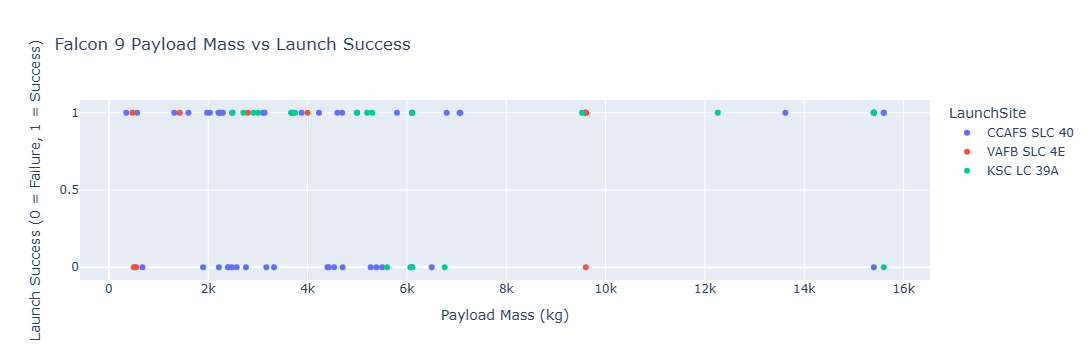

In [31]:
import plotly.express as px

fig = px.scatter(
    df,
    x="PayloadMass",
    y="Class",
    color="LaunchSite",
    hover_data=["FlightNumber", "Orbit"],
    title="Falcon 9 Payload Mass vs Launch Success"
)

fig.update_layout(
    xaxis_title="Payload Mass (kg)",
    yaxis_title="Launch Success (0 = Failure, 1 = Success)"
)

fig.show()

##  Predictive Analysis — Classification


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = df[[
    "FlightNumber",
    "PayloadMass",
    "LaunchSite",
    "Orbit"
]]

y = df["Class"]

numeric_features = [
    "FlightNumber",
    "PayloadMass"
]

categorical_features = [
    "LaunchSite",
    "Orbit"
]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

accuracy

0.7777777777777778

## Conclusion and Key Insights

The SpaceX Falcon 9 launch analysis provided useful insights into the factors associated with successful first-stage landings.

### Key Findings

- Launch success varies across different launch sites and orbit types.
- Payload mass shows different success and failure patterns depending on mission characteristics.
- Exploratory data analysis helped identify relationships between flight number, payload mass, orbit, launch site, and landing outcome.
- SQL analysis provided structured summaries of launch activity, payload mass, and success rates.
- Folium maps provided a geographic view of Falcon 9 launch sites and landing outcomes.
- Interactive Plotly visualizations made it easier to explore launch performance across different mission conditions.
- The Logistic Regression model achieved a test accuracy of approximately **77.78%**.

### Innovative Insight

The analysis suggests that Falcon 9 landing success should not be evaluated using a single mission characteristic. Launch site, orbit, payload mass, and flight experience collectively provide more meaningful information about landing outcomes.

### Conclusion

This project demonstrates an end-to-end data science workflow involving data preparation, exploratory analysis, SQL, interactive visualization, geographic analysis, and machine learning. The results show how historical launch data can be transformed into useful insights and used to build a predictive model for Falcon 9 first-stage landing success.